# Bab 2 — Data and Sampling Distributions

Nama : OMAR AL FARIZY HUTAGALUNG

NIM : 101032300034

KELAS : TK 47 03

Chapter ini membahas bagaimana sampel digunakan untuk memahami populasi dan bagaimana hasil statistik dari suatu sampel dapat berubah apabila proses sampling diulang.

Dalam analisis data, kita sering tidak memiliki akses terhadap seluruh populasi. Oleh karena itu, kita menggunakan sampel sebagai representasi populasi. Masalahnya, sampel yang berbeda dapat menghasilkan nilai statistik yang berbeda pula.

Chapter ini membahas beberapa konsep penting untuk memahami variasi tersebut, yaitu:

- random sampling dan sample bias,
- sampling distribution,
- central limit theorem,
- standard error,
- bootstrap,
- confidence interval,
- normal distribution,
- long-tailed distributions,
- Student's t-distribution,
- binomial distribution, dan
- Poisson distribution.

Tujuan utama chapter ini adalah memahami bahwa statistik yang dihitung dari sampel bukan merupakan nilai yang selalu tetap. Nilai tersebut memiliki variabilitas yang perlu dipahami ketika kita menarik kesimpulan mengenai populasi.

In [1]:
%matplotlib inline

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.utils import resample

from IPython.display import display, Markdown
from importlib.metadata import version


ROOT = Path.cwd()

if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA = ROOT / "data"

if not DATA.exists():
    raise FileNotFoundError(
        f"Folder data tidak ditemukan. Current path: {ROOT}"
    )

SEED = 42

np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.dpi": 110
})

pd.set_option("display.max_columns", 25)

print("Python:", sys.version.split()[0])
print("Interpreter:", sys.executable)
print("Data:", DATA.relative_to(ROOT))

income = pd.read_csv(
    DATA / "loans_income.csv"
).squeeze("columns")

sp500 = pd.read_csv(
    DATA / "sp500_data.csv.gz",
    index_col=0
)

assert income.notna().all()
display(
    income.describe().to_frame("pendapatan tahunan (USD)")
)

print(
    "S&P 500:",
    len(sp500),
    "observasi; missing =",
    sp500.isna().sum().sum()
)

Python: 3.12.10
Interpreter: d:\Folder Perkuliahan\SEMESTER 7\ML dan DL\Repository Clone\Practical-Statistics-for-Data-Scientists\.venv\Scripts\python.exe
Data: data


,pendapatan tahunan (USD)
count,50000.00000
mean,68760.51844
std,32872.03537
min,4000.00000
25%,45000.00000
50%,62000.00000
75%,85000.00000
max,199000.00000


S&P 500: 5647 observasi; missing = 0


## 2. Random Sampling and Sample Bias

### Random Sampling

Sampel merupakan sebagian data yang diambil dari suatu populasi. Dalam statistik, populasi tidak selalu berarti populasi manusia, tetapi dapat berupa keseluruhan kumpulan data yang ingin kita pelajari.

Random sampling adalah proses pemilihan sampel di mana setiap anggota populasi yang tersedia memiliki kesempatan yang sama untuk dipilih. Hasil dari proses tersebut disebut **simple random sample**.

Sampling dapat dilakukan dengan dua cara:

- **Sampling with replacement** — data yang sudah dipilih dikembalikan ke populasi sehingga masih dapat dipilih kembali.
- **Sampling without replacement** — data yang sudah dipilih tidak dapat dipilih kembali.

Random sampling penting karena cara kita memilih sampel dapat memengaruhi hasil analisis. Sampel yang tidak representatif dapat menghasilkan kesimpulan yang berbeda dari kondisi populasi sebenarnya.


### Sample Bias

**Sample bias** terjadi ketika sampel yang digunakan tidak merepresentasikan populasi yang ingin dipelajari.

Jumlah data yang besar tidak selalu menjamin hasil analisis yang baik. Kualitas dan representativitas data juga penting. Jika proses pengambilan sampel menghasilkan kelompok yang berbeda secara sistematis dari populasi, maka estimasi yang diperoleh dapat mengalami bias.

Contohnya, jika kita ingin mengetahui pendapatan seluruh pemohon pinjaman tetapi hanya mengambil sampel dari kelompok dengan karakteristik tertentu, hasil rata-rata sampel belum tentu menggambarkan pendapatan seluruh populasi pemohon pinjaman.

Karena itu, dalam analisis statistik kita tidak hanya perlu memperhatikan **berapa banyak data yang digunakan**, tetapi juga **bagaimana data tersebut diperoleh**.

### Ilustrasi Bias Sistematis

Bias tidak selalu dapat diperbaiki hanya dengan menambah jumlah data. Jika seluruh pengukuran mengalami penyimpangan yang sistematis, penambahan data dapat membuat hasil menjadi lebih konsisten tetapi tetap berada jauh dari nilai yang sebenarnya.

Pada ilustrasi berikut, kedua kumpulan titik memiliki tingkat noise yang sama. Perbedaannya adalah panel kedua memiliki **offset sistematis** sebesar `+0,65` pada kedua koordinat.

Ilustrasi ini menunjukkan perbedaan antara variasi acak dan bias sistematis:

- **Variasi acak (random variation)** menyebabkan hasil pengukuran menyebar di sekitar nilai target.
- **Bias sistematis (systematic bias)** menyebabkan hasil pengukuran bergeser secara konsisten dari nilai target.

Dengan demikian, mengurangi noise dan menghilangkan bias merupakan dua masalah yang berbeda dalam pengumpulan data.

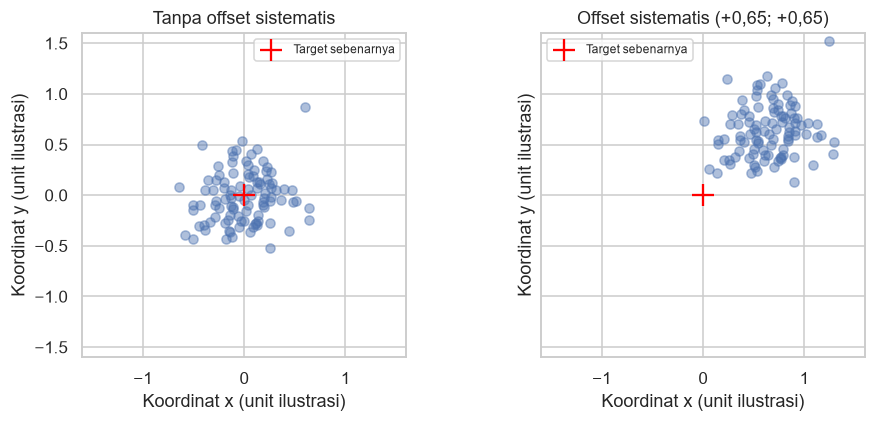

In [2]:
rng = np.random.default_rng(SEED)
noise = rng.normal(0, .3, (100,2))
fig,axes = plt.subplots(1,2,figsize=(9,4),sharex=True,sharey=True)
for ax,points,title in zip(axes,[noise,noise+[.65,.65]],['Tanpa offset sistematis','Offset sistematis (+0,65; +0,65)']):
    ax.scatter(points[:,0],points[:,1],alpha=.45)
    ax.scatter(0,0,marker='+',s=200,c='red',label='Target sebenarnya')
    ax.set(xlim=(-1.6,1.6),ylim=(-1.6,1.6),xlabel='Koordinat x (unit ilustrasi)',
           ylabel='Koordinat y (unit ilustrasi)',title=title,aspect='equal')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [3]:
sample_preview = income.sample(n=10, replace=False, random_state=SEED)
display(sample_preview.rename('sampel pendapatan (USD)').to_frame())
assert sample_preview.index.is_unique

,sampel pendapatan (USD)
33553,92000
9427,50000
199,40000
12447,95000
39489,135000
42724,70000
10822,100000
49498,80000
4144,26300
36958,100000


<a id="c2-04"></a>
## Ukuran Versus Kualitas

Sampel kecil yang bersih dan representatif bisa lebih berguna daripada data sangat besar yang namun bias. Pemeriksaan missing value, unit, dan pencilan juga lebih mudah pada subset awal. Akan tetapi, proses jarang dan matriks sangat sparse memerlukan banyak data agar contoh relevan terkumpul. Buku memakai pencarian web sebagai ilustrasi: sebuah kombinasi kueri langka membutuhkan volume keseluruhan besar.

<a id="c2-05"></a>
## Sample Mean VS Population Mean

Mean sampel $\bar{x}=\frac{1}{n}\sum_i x_i$ mengestimasi mean populasi $\mu$. Huruf $n$ menunjukkan ukuran sampel, $N$ ukuran populasi. Parameter populasi tetap tetapi biasanya tidak diketahui; statistik sampel dapat berubah.

Di bawah ini $\mu_{emp}$ adalah mean seluruh file, hanya benchmark empiris untuk latihan. Menyebutnya mean pendapatan seluruh AS tidak dibenarkan.

In [4]:
print(f'Mean populasi empiris N={len(income):,}: USD {income.mean():,.2f}')
print(f'Mean sampel n=10: USD {sample_preview.mean():,.2f}')

Mean populasi empiris N=50,000: USD 68,760.52
Mean sampel n=10: USD 78,830.00


### Selection Bias

**Selection bias** merupakan bentuk bias yang muncul ketika proses pemilihan data menyebabkan sebagian kelompok lebih mungkin masuk ke dalam analisis dibandingkan kelompok lainnya.

Selection bias dapat muncul dalam berbagai bentuk, misalnya:

- nonrandom sampling,
- memilih data tertentu setelah melihat hasilnya,
- memilih periode waktu tertentu yang menghasilkan pola yang menarik,
- atau menghentikan eksperimen ketika hasilnya terlihat menarik.

Masalah utama dari selection bias adalah hasil yang diperoleh dapat terlihat meyakinkan, tetapi sebenarnya dipengaruhi oleh cara data dipilih.

In [5]:
p_ten_heads = .5**10
p_any = -np.expm1(20000*np.log1p(-p_ten_heads))
print(f'P(10 heads untuk satu orang) = {p_ten_heads:.8f}')
print(f'P(setidaknya satu dari 20.000) = {p_any:.10f}')

P(10 heads untuk satu orang) = 0.00097656
P(setidaknya satu dari 20.000) = 0.9999999967


**Interpretasi**
 Memilih pemenang setelah 20.000 percobaan memberi kesan keahlian yang bisa dijelaskan oleh peluang biasa. Rumus ini mengasumsikan koin adil dan percobaan independen.

### Regression to the Mean

**Regression to the mean** adalah fenomena ketika pengamatan yang sangat ekstrem cenderung diikuti oleh pengamatan yang lebih mendekati nilai tengah.

Hal ini dapat terjadi ketika suatu hasil ekstrem merupakan kombinasi dari faktor yang relatif konsisten dan variasi acak.

Konsep ini berbeda dari **linear regression**. Regression to the mean merupakan fenomena statistik mengenai perubahan pengamatan ekstrem pada pengukuran berikutnya, sedangkan linear regression merupakan metode untuk memodelkan hubungan antara variabel.

### Simulasi Sampling Distribution

Untuk melihat perbedaan antara data distribution dan sampling distribution, kita dapat melakukan simulasi menggunakan data pendapatan.

Pertama, kita melihat distribusi nilai individual. Selanjutnya, kita mengambil banyak sampel dan menghitung mean dari setiap sampel.

Pada simulasi ini digunakan:

- 1.000 nilai individual,
- 1.000 sample mean dengan ukuran sampel `n = 5`,
- 1.000 sample mean dengan ukuran sampel `n = 20`.

Dengan membandingkan ketiga distribusi tersebut, kita dapat melihat bahwa mean dari sampel memiliki distribusi yang lebih teratur dibandingkan distribusi nilai individual. Ketika ukuran sampel meningkat dari 5 menjadi 20, distribusi sample mean juga menjadi lebih sempit.

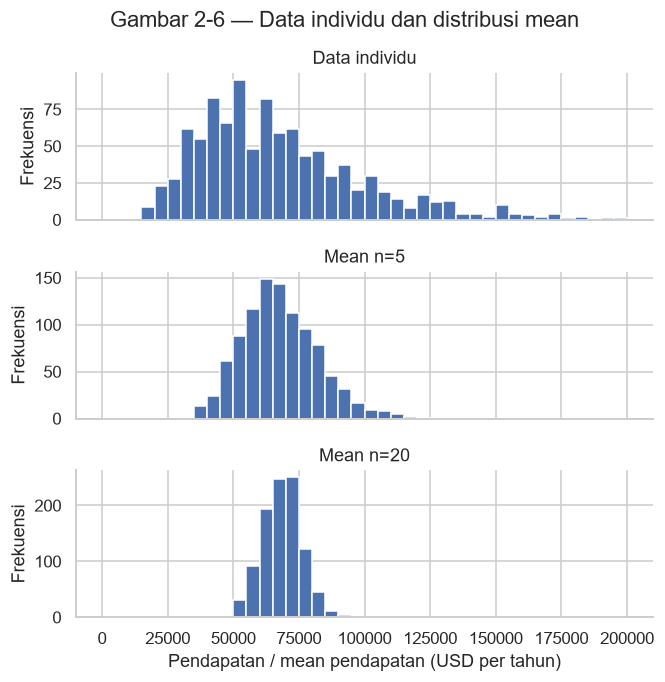

,mean,std,skew
type,,,
Data individu,66536.47300,31383.510673,1.084794
Mean n=5,67953.97060,14619.295728,0.555211
Mean n=20,68693.53745,7433.010376,0.148072


Jumlah hasil di luar USD0–200.000:


,outside
type,
Data individu,0
Mean n=5,0
Mean n=20,0


In [6]:
rs = np.random.RandomState(SEED)
sampling = pd.concat([
    pd.DataFrame({'income':income.sample(1000,random_state=rs).to_numpy(),'type':'Data individu'}),
    pd.DataFrame({'income':[income.sample(5,random_state=rs).mean() for _ in range(1000)],'type':'Mean n=5'}),
    pd.DataFrame({'income':[income.sample(20,random_state=rs).mean() for _ in range(1000)],'type':'Mean n=20'}),
],ignore_index=True)
g=sns.FacetGrid(sampling,col='type',col_wrap=1,height=2,aspect=3,sharey=False)
g.map(plt.hist,'income',range=[0,200000],bins=40)
g.set_axis_labels('Pendapatan / mean pendapatan (USD per tahun)','Frekuensi')
g.set_titles('{col_name}')
g.figure.suptitle('Gambar 2-6 — Data individu dan distribusi mean',y=1.03)
plt.show()
display(sampling.groupby('type',sort=False).income.agg(['mean','std','skew']))
print('Jumlah hasil di luar USD0–200.000:')
display(sampling.assign(outside=~sampling.income.between(0,200000))
        .groupby('type',sort=False).outside.sum().to_frame())

**Interpretasi**

Pendapatan individu menceng ke kanan. Mean dari 20 pengamatan lebih terpusat dan kurang menceng daripada nilai individu. Merata-ratakan menurunkan variasi statistik; tidak mengubah distribusi pendapatan orang sebenarnya.

### Central Limit Theorem

**Central Limit Theorem (CLT)** menjelaskan bahwa sampling distribution dari suatu sample statistic seperti mean cenderung mendekati distribusi normal ketika ukuran sampel semakin besar.

Hal ini berlaku meskipun distribusi data awal tidak berbentuk normal, selama kondisi yang diperlukan untuk penerapan CLT terpenuhi.

Dalam praktik data science, CLT penting karena memungkinkan kita menggunakan pendekatan distribusi normal untuk memahami perilaku sample statistic.

Namun, CLT tidak berarti bahwa data asli harus berdistribusi normal. Yang menjadi lebih mendekati normal adalah **sampling distribution dari sample statistic** ketika ukuran sampel meningkat.

### Standard Error

**Standard error (SE)** merupakan ukuran variabilitas dari suatu sample statistic apabila proses sampling dilakukan berulang kali.

Standard error berbeda dari standard deviation.

- **Standard deviation** mengukur seberapa tersebar nilai individual dalam suatu data set.
- **Standard error** mengukur seberapa besar suatu sample statistic, seperti mean, dapat berubah dari satu sampel ke sampel lainnya.

Untuk sample mean, standard error dapat dihitung dengan pendekatan:

$$
SE = \frac{s}{\sqrt{n}}
$$

dengan:

- $s$ = standard deviation sampel,
- $n$ = ukuran sampel.

Dari rumus tersebut terlihat bahwa standard error akan semakin kecil ketika ukuran sampel meningkat. Artinya, sample mean cenderung menjadi lebih stabil ketika menggunakan sampel yang lebih besar.

In [7]:
display(pd.DataFrame([
    {'n':k,'SE rumus (USD)':income.std(ddof=1)/np.sqrt(k),
     'SD mean simulasi (USD)':sampling.loc[sampling.type==f'Mean n={k}','income'].std(ddof=1)}
    for k in [5,20]]))

,n,SE rumus (USD),SD mean simulasi (USD)
0,5,14700.821129,14619.295728
1,20,7350.410565,7433.010376


### Interpretasi

Hasil simulasi menunjukkan bahwa standard deviation dari kumpulan sample mean semakin kecil ketika ukuran sampel diperbesar.

Hal ini sesuai dengan konsep standard error. Dengan ukuran sampel yang lebih besar, variasi sample mean dari satu sampel ke sampel lainnya menjadi lebih kecil.

Dengan demikian, meningkatkan ukuran sampel tidak hanya menambah jumlah data, tetapi juga dapat membuat estimasi statistik menjadi lebih stabil.**Interpretasi dan catatan belajar.** SD dari 1.000 mean mendekati SE teoretis, dengan variasi Monte Carlo. Selisih kecil wajar karena hanya 1.000 pengulangan dan distribusi pendapatan memiliki ekor panjang.

### Simulasi Sampling Distribution

Untuk melihat perbedaan antara data distribution dan sampling distribution, kita dapat melakukan simulasi menggunakan data pendapatan.

Pertama, kita melihat distribusi nilai individual. Selanjutnya, kita mengambil banyak sampel dan menghitung mean dari setiap sampel.

Pada simulasi ini digunakan:

- 1.000 nilai individual,
- 1.000 sample mean dengan ukuran sampel `n = 5`,
- 1.000 sample mean dengan ukuran sampel `n = 20`.

Dengan membandingkan ketiga distribusi tersebut, kita dapat melihat bahwa mean dari sampel memiliki distribusi yang lebih teratur dibandingkan distribusi nilai individual. Ketika ukuran sampel meningkat dari 5 menjadi 20, distribusi sample mean juga menjadi lebih sempit.

### Simulasi Bootstrap

Pada bagian ini kita menggunakan data pendapatan (`income`) untuk memperkirakan variabilitas median menggunakan bootstrap.

Prosesnya dilakukan dengan:

1. mengambil bootstrap sample dari data `income` dengan replacement;
2. menghitung median dari bootstrap sample;
3. mengulangi proses tersebut sebanyak 1.000 kali;
4. mengumpulkan seluruh median yang diperoleh menjadi bootstrap distribution.

Dari bootstrap distribution tersebut, kita dapat menghitung:

- median dari hasil bootstrap,
- bias bootstrap,
- standard error bootstrap.

Standard error bootstrap digunakan untuk memperkirakan seberapa besar median sampel dapat berubah apabila proses sampling diulang.

In [8]:
rs_boot = np.random.RandomState(SEED)
boot_median = pd.Series([resample(income,random_state=rs_boot).median() for _ in range(1000)])
boot_summary = pd.Series({'median asli (USD)':income.median(),
                          'bias bootstrap (USD)':boot_median.mean()-income.median(),
                          'SE bootstrap (USD)':boot_median.std(ddof=1)})
display(boot_summary.to_frame('hasil aktual'))
assert income.median()==62000
print('Acuan R buku: median 62000; bias -70.5595; SE 209.1515 (hasil acak).')

,hasil aktual
median asli (USD),62000.000000
bias bootstrap (USD),-75.214500
SE bootstrap (USD),219.321518


Acuan R buku: median 62000; bias -70.5595; SE 209.1515 (hasil acak).


### Interpretasi

Bootstrap menghasilkan distribusi dari median yang diperoleh dari banyak bootstrap sample.

Median dari data asli digunakan sebagai estimasi awal. Selanjutnya, median dari setiap bootstrap sample dibandingkan dengan median asli.

**Bias bootstrap** menunjukkan perbedaan rata-rata hasil bootstrap dengan estimasi dari data asli.

**Standard error bootstrap** menunjukkan tingkat variabilitas median di antara bootstrap sample.

Jika standard error relatif kecil, hasil estimasi median cenderung lebih stabil terhadap perubahan sampel. Sebaliknya, standard error yang lebih besar menunjukkan bahwa estimasi lebih bervariasi ketika proses sampling diulang.

### Resampling dan Bootstrapping

Istilah **resampling** dan **bootstrapping** sering digunakan dalam konteks yang berdekatan, tetapi keduanya tidak selalu berarti hal yang sama.

**Resampling** merupakan istilah yang lebih umum untuk proses mengambil sampel berulang dari data yang tersedia. Resampling dapat mencakup bootstrap maupun prosedur permutation.

**Bootstrapping** secara khusus mengacu pada pengambilan sampel **dengan replacement** dari observed data set.

Jadi, bootstrap merupakan salah satu bentuk resampling dengan karakteristik utama berupa sampling with replacement.

## 5. Confidence Intervals

Confidence interval digunakan untuk menyatakan ketidakpastian di sekitar suatu estimasi statistik.

Sebuah sample statistic seperti mean atau median hanya memberikan **point estimate**, yaitu satu nilai yang diperoleh dari sampel. Karena sampel dapat berbeda apabila proses sampling diulang, nilai tersebut juga memiliki ketidakpastian.

Confidence interval memberikan suatu rentang nilai yang dibentuk berdasarkan prosedur statistik tertentu.

Confidence interval selalu disertai **confidence level**, misalnya 90% atau 95%.

Dalam konteks bootstrap, confidence interval dapat diperoleh dengan mengambil bagian tengah dari bootstrap distribution suatu sample statistic.

,batas bawah (USD),batas atas (USD)
90%,43212.4500,70233.4400
95%,41262.2225,72893.7725


Mean sampel 20: USD 55,734.10; mean seluruh file: USD 68,760.52


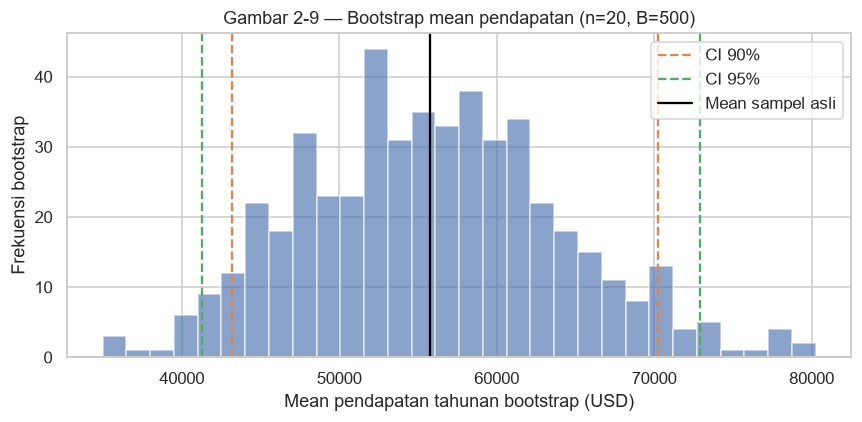

In [9]:
rs_ci=np.random.RandomState(3)
sample20=resample(income,n_samples=20,replace=False,random_state=rs_ci)
boot_mean=pd.Series([resample(sample20,random_state=rs_ci).mean() for _ in range(500)])
ci90=boot_mean.quantile([.05,.95]).to_numpy()
ci95=boot_mean.quantile([.025,.975]).to_numpy()
display(pd.DataFrame([ci90,ci95],index=['90%','95%'],columns=['batas bawah (USD)','batas atas (USD)']))
print(f'Mean sampel 20: USD {sample20.mean():,.2f}; mean seluruh file: USD {income.mean():,.2f}')
fig,ax=plt.subplots(figsize=(8,4))
ax.hist(boot_mean,bins=30,alpha=.65)
for ci,color,label in [(ci90,'C1','CI 90%'),(ci95,'C2','CI 95%')]:
    for j,x in enumerate(ci): ax.axvline(x,color=color,ls='--',label=label if j==0 else None)
ax.axvline(sample20.mean(),color='black',label='Mean sampel asli')
ax.set(title='Gambar 2-9 — Bootstrap mean pendapatan (n=20, B=500)',
       xlabel='Mean pendapatan tahunan bootstrap (USD)',ylabel='Frekuensi bootstrap')
ax.legend(); plt.tight_layout(); plt.show()
assert ci95[0] <= ci90[0] <= ci90[1] <= ci95[1]

### Interpretasi Confidence Level

Confidence level tidak sebaiknya diartikan sebagai probabilitas bahwa nilai parameter sebenarnya berada di dalam interval yang sudah diperoleh.

Sebagai gantinya, confidence level berkaitan dengan perilaku prosedur ketika proses sampling dilakukan berulang kali.

Misalnya, confidence interval 90% dapat dipahami sebagai prosedur yang dalam jangka panjang menghasilkan interval yang mencakup statistik yang menjadi perhatian sekitar 90% dari waktu, ketika prosedur sampling yang sama digunakan.

Interpretasi ini penting karena confidence interval sering kali disalahartikan sebagai probabilitas langsung terhadap parameter populasi.

## 6. Normal Distribution

Normal distribution merupakan distribusi berbentuk lonceng (*bell-shaped distribution*) yang banyak digunakan dalam statistik.

Distribusi ini memiliki bentuk yang simetris terhadap mean. Pada distribusi normal, sebagian besar nilai berada di sekitar mean dan semakin sedikit nilai yang berada jauh dari mean.

Dalam distribusi normal:

- sekitar 68% data berada dalam satu standard deviation dari mean;
- sekitar 95% data berada dalam dua standard deviation dari mean.

Distribusi normal juga penting karena banyak **sample statistic** memiliki sampling distribution yang mendekati bentuk normal.

Namun, hal ini tidak berarti bahwa sebagian besar data mentah (*raw data*) selalu berdistribusi normal. Banyak data nyata memiliki distribusi yang tidak normal.

Karena itu, asumsi distribusi normal sebaiknya digunakan dengan memperhatikan karakteristik data dan konteks analisis.

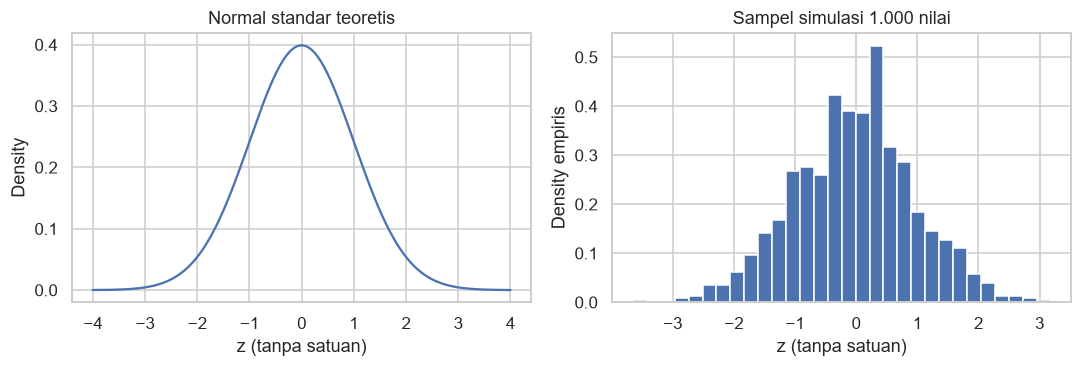

P(|Z| ≤ 1) = 0.6826894921370859
P(|Z| ≤ 2) = 0.9544997361036416


In [10]:
x=np.linspace(-4,4,400)
rng_normal=np.random.default_rng(SEED)
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
axes[0].plot(x,stats.norm.pdf(x)); axes[0].set(title='Normal standar teoretis',ylabel='Density')
axes[1].hist(stats.norm.rvs(size=1000,random_state=rng_normal),bins=30,density=True)
axes[1].set(title='Sampel simulasi 1.000 nilai',ylabel='Density empiris')
for ax in axes: ax.set_xlabel('z (tanpa satuan)')
plt.tight_layout(); plt.show()
print('P(|Z| ≤ 1) =',stats.norm.cdf(1)-stats.norm.cdf(-1))
print('P(|Z| ≤ 2) =',stats.norm.cdf(2)-stats.norm.cdf(-2))

### Interpretasi

Kurva normal memiliki bentuk yang simetris dengan pusat distribusi berada pada mean.

Semakin jauh suatu nilai dari mean, semakin kecil density-nya. Hal ini menunjukkan bahwa nilai yang sangat jauh dari pusat distribusi memiliki proporsi yang lebih kecil dalam distribusi normal.

Pada distribusi normal standar, mean berada pada `0` dan standard deviation bernilai `1`.**Interpretasi dan catatan belajar.** Histogram sampel hanya mendekati kurva populasi; ketidakrataan muncul dari jumlah sampel terbatas. Kurva ini merekonstruksi gagasan Gambar 2-1 dan 2-10 dengan simulasi yang dinyatakan eksplisit.

## 7. Standard Normal and QQ-Plots

### Standard Normal

Standard normal distribution merupakan bentuk khusus dari distribusi normal yang memiliki:

- mean = `0`
- standard deviation = `1`

Suatu nilai dapat diubah menjadi **z-score** dengan melakukan standardisasi:

$$
z = \frac{x-\mu}{\sigma}
$$

dengan:

- $x$ = nilai pengamatan,
- $\mu$ = mean,
- $\sigma$ = standard deviation.

Z-score menunjukkan posisi suatu nilai relatif terhadap mean dalam satuan standard deviation.

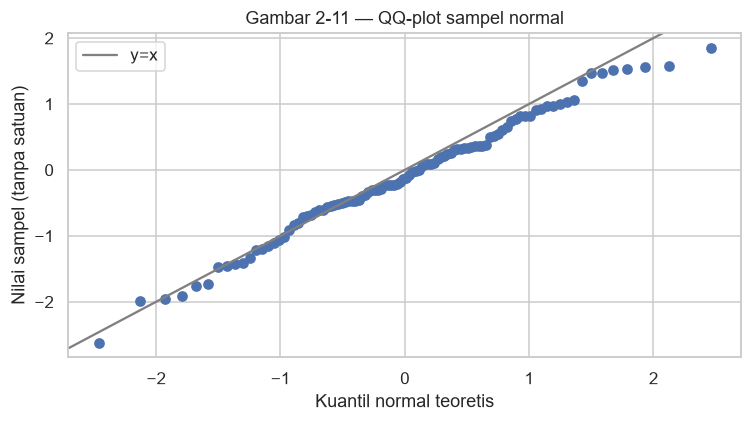

In [11]:
normal_sample=stats.norm.rvs(size=100,random_state=np.random.RandomState(SEED))
fig,ax=plt.subplots()
stats.probplot(normal_sample,dist='norm',fit=False,plot=ax)
ax.axline((0,0),(1,1),color='gray',label='y=x')
ax.set(title='Gambar 2-11 — QQ-plot sampel normal',xlabel='Kuantil normal teoretis',ylabel='Nilai sampel (tanpa satuan)')
ax.legend(); plt.tight_layout(); plt.show()

### Interpretasi QQ-Plot

QQ-Plot memberikan cara visual untuk mengevaluasi asumsi distribusi.

Hal yang perlu diperhatikan bukan hanya apakah seluruh titik tepat berada pada garis, tetapi juga pola penyimpangannya.

Penyimpangan pada bagian tengah distribusi dan bagian ekor dapat memberikan informasi yang berbeda mengenai bentuk distribusi data.

Dengan demikian, QQ-Plot dapat digunakan sebagai salah satu alat eksplorasi sebelum menggunakan pendekatan statistik yang mengasumsikan distribusi tertentu.

## 8. Long-Tailed Distributions

Tidak semua data memiliki bentuk distribusi normal.

Beberapa distribusi memiliki **long tail**, yaitu bagian ekor distribusi yang memanjang dan mengandung nilai-nilai ekstrem.

Dalam data science, distribusi seperti ini cukup umum. Contohnya dapat muncul pada data pendapatan, harga rumah, ukuran transaksi, dan berbagai pengukuran lainnya.

Keberadaan long tail penting karena beberapa nilai ekstrem dapat memberikan pengaruh yang besar terhadap statistik seperti mean dan standard deviation.

Karena itu, sebelum menggunakan asumsi distribusi normal, kita perlu melihat bentuk distribusi data terlebih dahulu.

Observasi raw: 5647 | dibuang karena ≤0: 4034 | hasil diff: 1612


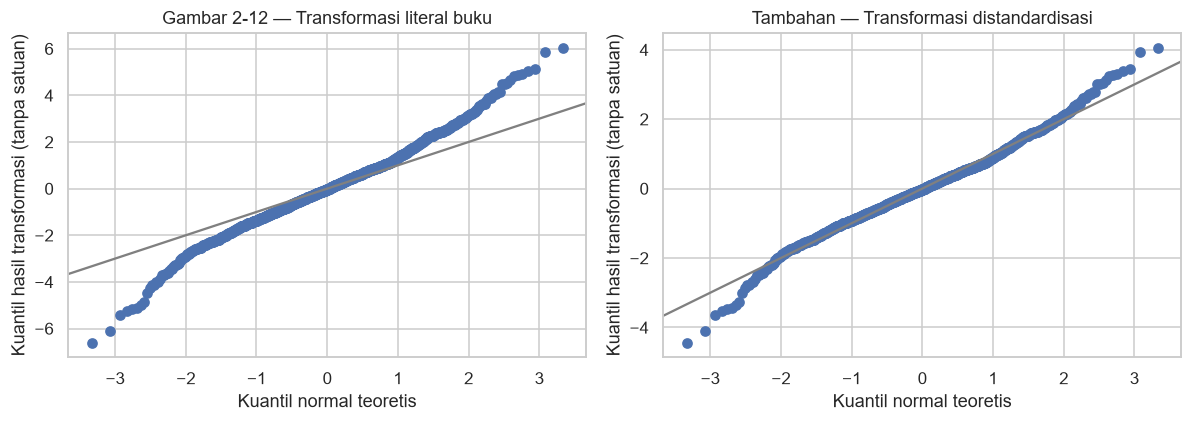

,transformasi buku
count,1612.000000
mean,0.001556
std,1.488791
min,-6.605298
1%,-3.695251
5%,-2.285249
95%,2.456536
99%,3.900856
max,6.037870


In [12]:
nflx_raw=sp500.NFLX
nflx=np.diff(np.log(nflx_raw[nflx_raw>0]))
print('Observasi raw:',len(nflx_raw),'| dibuang karena ≤0:',int((nflx_raw<=0).sum()),
      '| hasil diff:',len(nflx))
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,vals,title in [(axes[0],nflx,'Gambar 2-12 — Transformasi literal buku'),
                       (axes[1],stats.zscore(nflx,ddof=1),'Tambahan — Transformasi distandardisasi')]:
    stats.probplot(vals,fit=False,plot=ax)
    ax.axline((0,0),(1,1),color='gray')
    ax.set(title=title,xlabel='Kuantil normal teoretis',ylabel='Kuantil hasil transformasi (tanpa satuan)')
plt.tight_layout(); plt.show()
display(pd.Series(nflx).describe(percentiles=[.01,.05,.95,.99]).to_frame('transformasi buku'))

### Interpretasi

Distribusi dengan ekor panjang memiliki sejumlah kecil pengamatan yang berada jauh dari pusat distribusi.

Nilai-nilai tersebut dapat menyebabkan mean bergeser dan meningkatkan standard deviation. Karena itu, statistik yang lebih robust seperti median dan percentile dapat menjadi pelengkap yang berguna ketika menganalisis data dengan distribusi yang memiliki ekor panjang.

Bentuk distribusi perlu diperiksa sebelum menentukan statistik ringkasan yang akan digunakan.

## 9. Student's t-Distribution

**Student's t-distribution** merupakan distribusi yang digunakan dalam berbagai prosedur statistik, terutama ketika ukuran sampel relatif kecil dan standard deviation populasi tidak diketahui.

Bentuk t-distribution menyerupai distribusi normal, tetapi memiliki ekor yang lebih berat.

Bentuk distribusi tersebut bergantung pada **degrees of freedom (df)**.

Ketika degrees of freedom meningkat, t-distribution semakin mendekati standard normal distribution.

Karena itu, t-distribution sering digunakan ketika kita memperkirakan mean populasi berdasarkan sampel dan perlu memperhitungkan ketidakpastian tambahan akibat estimasi standard deviation dari data sampel.

CI t 90% untuk mean sampel20: (np.float64(41235.62704493809), np.float64(70232.57295506191))


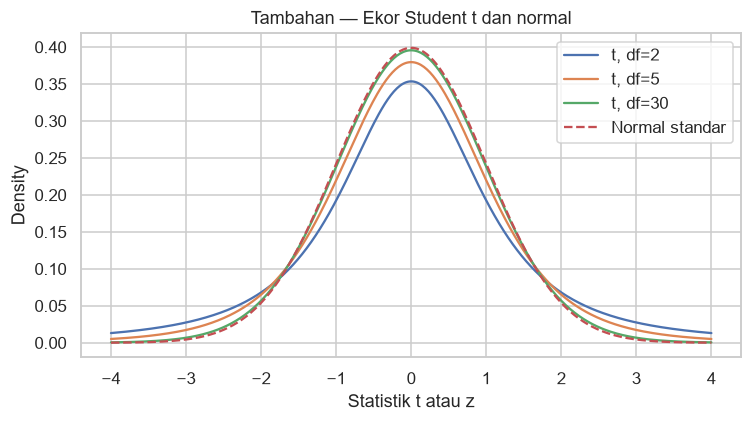

In [13]:
dfree=len(sample20)-1
half=stats.t.ppf(.95,df=dfree)*stats.sem(sample20)
print('CI t 90% untuk mean sampel20:',(sample20.mean()-half,sample20.mean()+half))
x=np.linspace(-4,4,400)
for dfree in [2,5,30]: plt.plot(x,stats.t.pdf(x,dfree),label=f't, df={dfree}')
plt.plot(x,stats.norm.pdf(x),ls='--',label='Normal standar')
plt.title('Tambahan — Ekor Student t dan normal'); plt.xlabel('Statistik t atau z'); plt.ylabel('Density')
plt.legend(); plt.tight_layout(); plt.show()

### Interpretasi

Grafik menunjukkan bahwa t-distribution berubah berdasarkan degrees of freedom.

Untuk degrees of freedom yang kecil, bagian ekor distribusi lebih tebal. Hal ini menunjukkan ketidakpastian yang lebih besar.

Ketika degrees of freedom meningkat, kurva semakin mendekati standard normal distribution.

Konsep ini penting dalam inferensi statistik karena ukuran sampel yang lebih kecil biasanya menghasilkan degrees of freedom yang lebih kecil.

## 10. Binomial Distribution

**Binomial distribution** digunakan untuk menggambarkan jumlah *success* yang diperoleh dari sejumlah *trial* ketika setiap trial memiliki dua kemungkinan hasil.

Dua hasil tersebut biasanya direpresentasikan sebagai:

- `1` = success
- `0` = failure

Istilah *success* tidak selalu berarti hasil yang positif atau diinginkan. Success hanya menunjukkan hasil yang menjadi perhatian dalam analisis.

Contohnya, pada analisis transaksi, sebuah transaksi yang mengalami fraud dapat dianggap sebagai `success` karena merupakan kejadian yang ingin dipelajari.

Binomial distribution ditentukan oleh dua parameter utama:

- `n` = jumlah trial
- `p` = probabilitas success pada setiap trial

Distribusi ini kemudian menggambarkan probabilitas memperoleh sejumlah success tertentu dari `n` trial.

In [14]:
pmf=stats.binom.pmf(2,n=5,p=.1)
cdf=stats.binom.cdf(2,n=5,p=.1)
print(f'P(X=2), n=5 p=0,1: {pmf:.4f}')
print(f'P(X≤2), n=5 p=0,1: {cdf:.5f}')
print(f'P(tanpa konversi dalam 200 klik), p=0,02: {stats.binom.pmf(0,200,.02):.6f}')
assert np.isclose(pmf,.0729)
assert np.isclose(cdf,.99144)

P(X=2), n=5 p=0,1: 0.0729
P(X≤2), n=5 p=0,1: 0.99144
P(tanpa konversi dalam 200 klik), p=0,02: 0.017588


### Interpretasi Probabilitas

`pmf` (*probability mass function*) digunakan untuk menghitung probabilitas mendapatkan **tepat sejumlah success tertentu**.

Sebagai contoh:

```text
stats.binom.pmf(2, n=5, p=0.1)

## 11. Chi-Square Distribution

**Chi-square distribution** merupakan distribusi yang digunakan untuk menganalisis data berupa jumlah atau **counts** yang berada dalam beberapa kategori.

Konsep utamanya adalah membandingkan nilai yang **diamati (observed)** dengan nilai yang **diharapkan (expected)** berdasarkan suatu model atau asumsi.

Chi-square statistic mengukur seberapa jauh observed values menyimpang dari expected values.

Secara umum:

- nilai chi-square yang kecil menunjukkan bahwa observed values relatif dekat dengan expected values;
- nilai chi-square yang besar menunjukkan bahwa observed values memiliki penyimpangan yang lebih besar dari expected values.

Chi-square distribution memiliki bentuk yang berbeda-beda tergantung pada **degrees of freedom**.

## 12. F-Distribution

**F-distribution** digunakan dalam eksperimen dan model statistik yang melibatkan data numerik atau data hasil pengukuran.

F-distribution berkaitan dengan **F-statistic**, yaitu rasio antara dua sumber variasi.

Dalam konteks perbandingan beberapa kelompok, F-statistic membandingkan:

- variasi antar-group means;
- variasi di dalam masing-masing group atau residual variability.

Secara sederhana, F-statistic membantu melihat apakah perbedaan antar kelompok cukup besar dibandingkan dengan variasi yang terjadi di dalam kelompok.

F-distribution memiliki beberapa bentuk yang bergantung pada **degrees of freedom**.

F-distribution banyak digunakan dalam **analysis of variance (ANOVA)** dan juga muncul dalam analisis linear regression.

## 13. Poisson and Related Distributions

Beberapa proses menghasilkan kejadian yang muncul secara acak dengan suatu **event rate** tertentu.

Contohnya:

- jumlah pengunjung yang datang ke sebuah website dalam satu menit;
- jumlah kendaraan yang melewati gerbang tol dalam satu periode;
- jumlah kesalahan pada sejumlah baris kode;
- jumlah kerusakan atau kejadian tertentu dalam suatu periode waktu.

Untuk situasi seperti ini, beberapa distribusi probabilitas dapat digunakan untuk memodelkan proses tersebut.

Tiga distribusi yang dibahas pada bagian ini adalah:

- **Poisson distribution** — jumlah kejadian dalam suatu interval waktu atau ruang;
- **Exponential distribution** — waktu atau jarak antara satu kejadian dengan kejadian berikutnya;
- **Weibull distribution** — perluasan exponential distribution ketika event rate dapat berubah terhadap waktu.

Parameter utama yang digunakan pada Poisson dan exponential distribution adalah **lambda (λ)**, yaitu event rate per unit waktu atau ruang.

## 14. Poisson Distributions

**Poisson distribution** digunakan untuk memodelkan jumlah kejadian yang terjadi dalam suatu interval waktu atau ruang ketika kejadian tersebut muncul secara acak dengan suatu event rate.

Parameter utama Poisson distribution adalah:

$$
\lambda
$$

Lambda (`λ`) menunjukkan **rata-rata jumlah kejadian dalam interval yang ditentukan**.

Salah satu karakteristik penting Poisson distribution adalah:

$$
Mean = \lambda
$$

dan

$$
Variance = \lambda
$$

Contohnya, jika rata-rata terdapat 2 panggilan customer service setiap menit, Poisson distribution dapat digunakan untuk memodelkan jumlah panggilan yang masuk dalam satu menit.

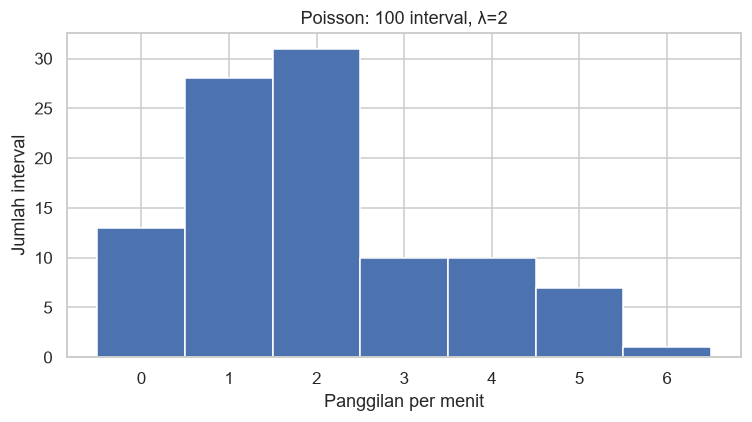

Mean simulasi: 2.01 | varians sampel: 2.111010101010101 | teori: 2


In [15]:
poisson_sample=stats.poisson.rvs(2,size=100,random_state=np.random.RandomState(SEED))
plt.hist(poisson_sample,bins=np.arange(poisson_sample.max()+2)-.5,edgecolor='white')
plt.title('Poisson: 100 interval, λ=2'); plt.xlabel('Panggilan per menit'); plt.ylabel('Jumlah interval')
plt.tight_layout(); plt.show()
print('Mean simulasi:',poisson_sample.mean(),'| varians sampel:',poisson_sample.var(ddof=1),'| teori: 2')

### Interpretasi Poisson Distribution

Hasil simulasi menunjukkan jumlah kejadian yang dapat muncul pada setiap interval.

Karena `lambda` merupakan rata-rata jumlah kejadian, distribusi akan memiliki pusat di sekitar nilai tersebut.

Dalam contoh dengan `lambda = 2`, sebagian besar interval akan memiliki jumlah kejadian yang berada di sekitar 2, tetapi beberapa interval dapat memiliki jumlah yang lebih kecil atau lebih besar.

Poisson distribution cocok digunakan ketika kita ingin memodelkan **jumlah kejadian per unit waktu atau ruang**, bukan waktu tunggu antar-kejadian.

## 15. Exponential Distribution

Jika Poisson distribution digunakan untuk menghitung **jumlah kejadian** dalam suatu interval, maka exponential distribution digunakan untuk memodelkan **waktu atau jarak antara satu kejadian dengan kejadian berikutnya**.

Contohnya:

- waktu antara kedatangan customer;
- jarak antara dua kendaraan;
- waktu antara dua panggilan customer service;
- waktu sampai terjadinya suatu event.

Exponential distribution menggunakan event rate `λ` sebagai parameter.

Hubungan antara Poisson dan exponential distribution dapat diringkas sebagai:

- **Poisson** → berapa banyak event yang terjadi dalam suatu interval;
- **Exponential** → berapa lama waktu atau jarak sampai event berikutnya.

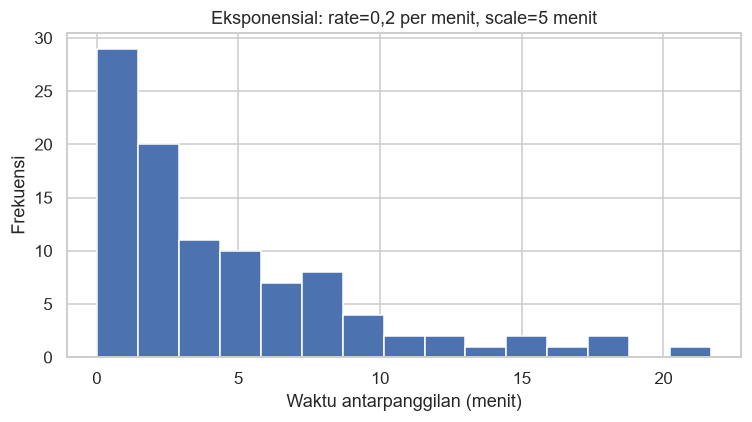

Mean simulasi = 4.574 menit; mean teori = 5 menit


In [16]:
exponential=stats.expon.rvs(scale=5,loc=0,size=100,random_state=np.random.RandomState(SEED))
plt.hist(exponential,bins=15,edgecolor='white')
plt.title('Eksponensial: rate=0,2 per menit, scale=5 menit')
plt.xlabel('Waktu antarpanggilan (menit)'); plt.ylabel('Frekuensi')
plt.tight_layout(); plt.show()
print(f'Mean simulasi = {exponential.mean():.3f} menit; mean teori = 5 menit')

### Interpretasi Exponential Distribution

Exponential distribution menggambarkan distribusi waktu atau jarak antara satu event dengan event berikutnya.

Sebagian besar waktu tunggu berada pada nilai yang relatif pendek, tetapi terdapat kemungkinan memperoleh waktu tunggu yang jauh lebih panjang.

Berbeda dengan Poisson distribution yang menghitung jumlah event dalam interval, exponential distribution berfokus pada **interval antara dua event**.

Keduanya menggunakan event rate yang sama, sehingga kedua distribusi tersebut memiliki hubungan yang erat.

## 16. Estimating the Failure Rate

Dalam beberapa aplikasi, event rate `λ` sudah diketahui atau dapat diperkirakan dari data sebelumnya.

Namun, untuk **rare events**, memperkirakan event rate dapat menjadi sulit karena jumlah kejadian yang tersedia sangat sedikit.

Contohnya adalah kegagalan mesin atau aircraft engine failure. Karena kejadian tersebut jarang terjadi, data historis mengenai waktu antar-kegagalan dapat sangat terbatas.

Jika belum pernah terjadi kegagalan selama periode tertentu, kita tetap dapat menggunakan informasi tersebut untuk memperkirakan batas atas event rate yang masuk akal.

Misalnya, jika tidak terdapat kegagalan selama 20 jam, event rate sebesar 1 kegagalan per jam menjadi kurang masuk akal.

Pendekatan yang dapat digunakan antara lain:

- simulasi;
- perhitungan probabilitas secara langsung;
- goodness-of-fit test apabila tersedia data yang cukup.

In [17]:
T=20
upper=-np.log(.05)/T
print(f'P(0 kegagalan dalam 20 jam bila rate=1/jam): {np.exp(-T):.3e}')
print(f'Batas atas satu sisi 95% rate setelah 0 kejadian / 20 jam: {upper:.4f} per jam')

P(0 kegagalan dalam 20 jam bila rate=1/jam): 2.061e-09
Batas atas satu sisi 95% rate setelah 0 kejadian / 20 jam: 0.1498 per jam


### Interpretasi

Masalah utama dalam rare-event analysis adalah jumlah kejadian yang diamati mungkin terlalu sedikit untuk memberikan estimasi event rate yang presisi.

Jika tidak ada failure yang diamati selama periode tertentu, hal tersebut tidak berarti bahwa failure rate sama dengan nol.

Sebaliknya, informasi tersebut dapat digunakan untuk menilai apakah suatu failure rate tertentu masih masuk akal.

Dengan melakukan simulasi atau menghitung probabilitas secara langsung, kita dapat mencari event rate yang menghasilkan peluang sangat kecil terhadap hasil observasi yang sebenarnya.

Jika terdapat data yang lebih banyak tetapi masih belum cukup untuk menghasilkan estimasi yang presisi, goodness-of-fit test dapat digunakan untuk membandingkan beberapa kemungkinan event rate dengan data yang diamati.

### Konsep Dasar

Weibull distribution digunakan ketika **event rate berubah terhadap waktu**. Ini membedakannya dari exponential distribution yang mengasumsikan bahwa event rate tetap konstan.

Situasi seperti kegagalan komponen mekanis sering menunjukkan pola seperti ini: semakin lama suatu komponen digunakan, risiko kegagalannya dapat berubah.

Weibull distribution merupakan pengembangan dari exponential distribution yang memungkinkan event rate berubah terhadap waktu.

### Shape Parameter (β)

Perubahan event rate ditentukan oleh **shape parameter**, yang dilambangkan dengan β (beta).

Interpretasinya:

- **β > 1** → probabilitas terjadinya event meningkat seiring waktu.
- **β < 1** → probabilitas terjadinya event menurun seiring waktu.
- **β = 1** → Weibull menjadi kasus khusus yang berkaitan dengan exponential distribution, dengan event rate konstan.

Dengan demikian, β memberikan informasi mengenai bagaimana risiko kejadian berubah terhadap waktu.

### Scale Parameter (η)

Parameter kedua adalah **scale parameter**, yang dilambangkan dengan η (eta).

Pada analisis time-to-failure, parameter ini digunakan untuk menyatakan **characteristic life**, yaitu skala waktu yang digunakan untuk menggambarkan lifetime atau waktu sampai terjadinya failure.

Berbeda dengan exponential distribution yang menggunakan parameter rate, Weibull menggunakan scale parameter η untuk menggambarkan karakteristik waktu kegagalan.

### Estimasi Parameter

Pada Weibull distribution terdapat dua parameter yang perlu diestimasi:

1. **β (shape parameter)** — menentukan bagaimana event rate berubah terhadap waktu.
2. **η (scale parameter)** — menentukan skala characteristic life.

Dalam praktiknya, software statistik digunakan untuk memodelkan data dan memperoleh estimasi distribusi Weibull yang paling sesuai dengan data.

### Simulasi Weibull Distribution

Python menyediakan `scipy.stats.weibull_min` untuk menghasilkan random numbers dari Weibull distribution.

Contoh:

```python
from scipy import stats

weibull_data = stats.weibull_min.rvs(
    1.5,
    scale=5000,
    size=100
)

weibull_data[:10]

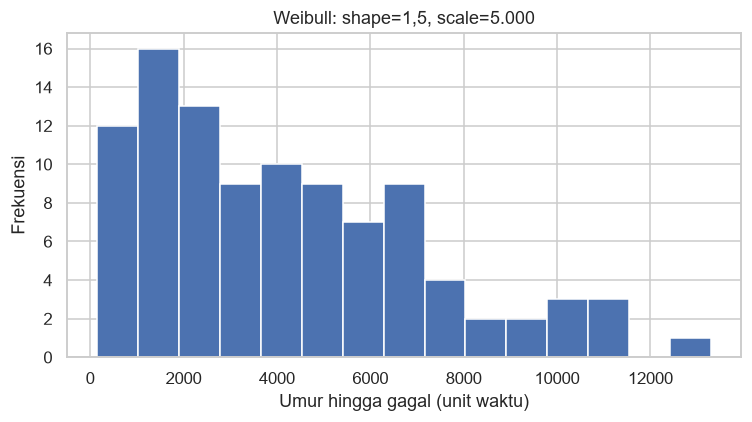

Mean simulasi: 4223.51; mean teori: 4513.73
P(T ≤ 5.000): 0.6321


In [18]:
weibull=stats.weibull_min.rvs(1.5,scale=5000,size=100,random_state=np.random.RandomState(SEED))
plt.hist(weibull,bins=15,edgecolor='white')
plt.title('Weibull: shape=1,5, scale=5.000')
plt.xlabel('Umur hingga gagal (unit waktu)'); plt.ylabel('Frekuensi')
plt.tight_layout(); plt.show()
print(f'Mean simulasi: {weibull.mean():.2f}; mean teori: {stats.weibull_min.mean(1.5,scale=5000):.2f}')
print(f'P(T ≤ 5.000): {stats.weibull_min.cdf(5000,1.5,scale=5000):.4f}')

## Summary

Chapter 2 membahas bagaimana sampling dan probability distributions digunakan untuk memahami variasi statistik dan membuat inferensi dari data.

Konsep utama yang dipelajari meliputi:

### Sampling

**Random sampling** memberikan kesempatan yang sama bagi setiap anggota populasi untuk dipilih menjadi sampel. Kualitas dan representativeness sampel sangat penting karena sample bias dapat menyebabkan kesimpulan yang tidak mewakili populasi.

### Sampling Distribution

Sampling distribution menunjukkan bagaimana suatu statistik, seperti mean, dapat bervariasi apabila proses sampling dilakukan berulang kali.

Konsep penting yang berkaitan dengannya adalah:

- Central Limit Theorem
- Standard Error
- Sampling variability

### Bootstrap

Bootstrap menggunakan resampling dari data yang tersedia untuk memperkirakan distribusi suatu statistik.

Metode ini berguna untuk:

- mengestimasi variability,
- membuat confidence interval,
- memahami ketidakpastian suatu estimasi.

### Confidence Interval

Confidence interval memberikan rentang nilai yang digunakan untuk mengestimasi parameter populasi berdasarkan data sampel.

Bootstrap dapat digunakan untuk memperoleh confidence interval tanpa terlalu bergantung pada asumsi distribusi tertentu.

### Probability Distributions

Chapter ini juga memperkenalkan beberapa probability distributions:

- Normal distribution
- Student's t-distribution
- Binomial distribution
- Chi-square distribution
- F-distribution
- Poisson distribution
- Exponential distribution
- Weibull distribution

Masing-masing distribution memiliki karakteristik dan penggunaan yang berbeda.

### Distribusi untuk Event dan Failure

Poisson distribution digunakan untuk memodelkan jumlah event dalam interval tertentu ketika event rate dianggap konstan.

Exponential distribution digunakan untuk memodelkan waktu atau jarak antara event ketika event rate konstan.

Weibull distribution memperluas konsep tersebut dengan memungkinkan event rate berubah terhadap waktu.

### Kesimpulan

Konsep utama Chapter 2 adalah bahwa data yang tersedia biasanya merupakan **sample**, sedangkan tujuan analisis adalah memahami karakteristik populasi yang lebih besar.

Sampling, resampling, confidence interval, dan probability distributions menyediakan berbagai cara untuk memahami **variability dan uncertainty** yang muncul dalam proses tersebut.